Import necessary libraries

In [2]:
library(dplyr)
library(censusapi)

library(usmap)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [9]:
acs_subject <- getCensus(
    name = "acs/acs5/subject",
    vintage = 2023, 
    vars = c(
        "NAME",
        "S1701_C01_001E", # Estimate!!Total!!Population for whom poverty status is determined
        "S1701_C03_001E"  # Estimate!!Percent below poverty level!!Population for whom poverty status is determined
        ), 
    region = "county:*",
    regionin = "state:11,24,51") # 54 is WV
nrow(acs_subject)
print(acs_subject %>% arrange(S1701_C03_001E))

[1] 158

    state county                                       NAME S1701_C01_001E
1      51    145                  Powhatan County, Virginia          29520
2      51    610                Falls Church city, Virginia          14518
3      51    075                 Goochland County, Virginia          24636
4      24    009                   Calvert County, Maryland          93318
5      51    107                   Loudoun County, Virginia         424861
6      24    027                    Howard County, Maryland         330837
7      51    179                  Stafford County, Virginia         156659
8      51    085                   Hanover County, Virginia         109403
9      51    127                  New Kent County, Virginia          23524
10     24    013                   Carroll County, Maryland         170501
11     51    199                      York County, Virginia          68904
12     24    003              Anne Arundel County, Maryland         580311
13     51    685         

In [10]:
acs_subject <- acs_subject %>% 
    mutate(
    fips = paste0(state, county), 
    bracket = case_when(
        S1701_C03_001E < 5 ~ "<5%",
        S1701_C03_001E >= 5 & S1701_C03_001E < 10 ~ "5-9.9%",
        S1701_C03_001E >= 10 & S1701_C03_001E < 15 ~ "10-14.9%",
        S1701_C03_001E >= 15 & S1701_C03_001E < 20 ~ "15-19.9%",
        S1701_C03_001E >= 20 ~ "20%+"
        ),
    bracket = factor(bracket, levels = c("<5%", "5-9.9%", "10-14.9%", "15-19.9%", "20%+"))
    )

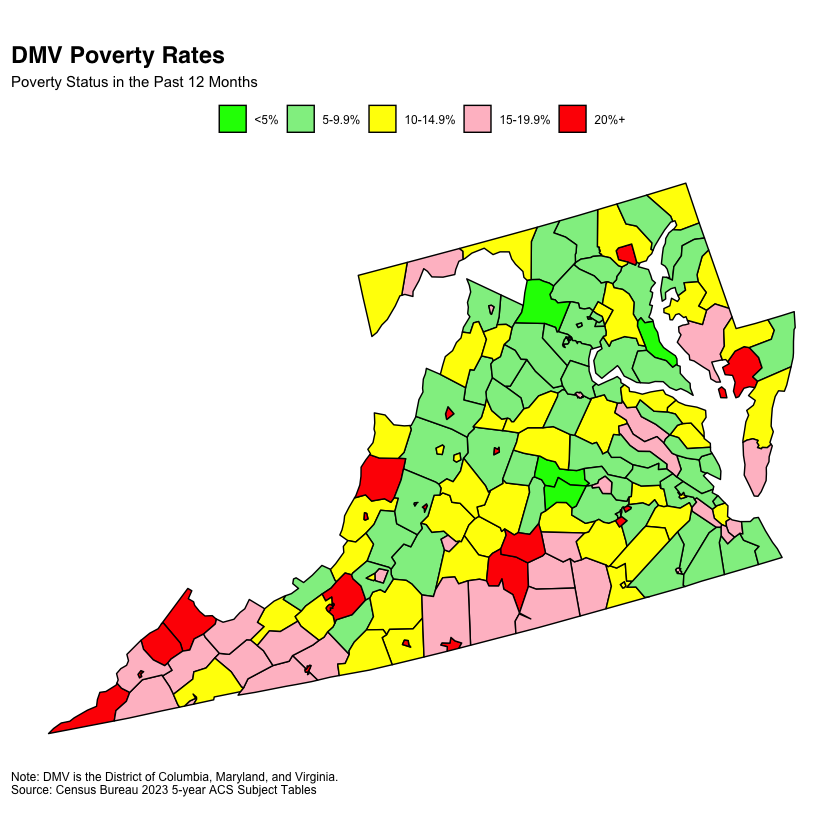

In [17]:
dmv_poverty <- plot_usmap("counties", include = c("VA", "DC", "MD"), data = acs_subject, values = "bracket") +
  scale_fill_manual(
    name = NULL,
    values = c(
      "<5%" = "green",
      "5-9.9%" = "lightgreen",
      "10-14.9%" = "yellow",
      "15-19.9%" = "pink",
      "20%+" = "red"
    )
  ) +
  labs(
    title = "DMV Poverty Rates",
    subtitle = "Poverty Status in the Past 12 Months",
    caption = 'Note: DMV is the District of Columbia, Maryland, and Virginia.\nSource: Census Bureau 2023 5-year ACS Subject Tables'
       ) + 
  theme(
    panel.background=element_blank(),
    legend.position = "top",
    plot.caption = element_text(hjust = 0),
    plot.title = element_text(family = "Helvetica", face = "bold", size = 14)
    )

  dmv_poverty

In [18]:
ggsave(
  "../plots/dmv_poverty.png",
  plot = dmv_poverty,
  width = 3.9*1.25,
  height = 3.2+(0.13*4),
  units = "in",
  dpi = 300,
  bg = "white"
  )